In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

# Positive Definite Matrices (Bowl shape (convex upward))
convex optimization


In [2]:
# Symmeritic matrix 
A = np.asarray([[3,1],
                [1,2]])

K,x = np.linalg.eig(A) # K -> eigenvalue, x -> eigenvector
origin = np.zeros(x.shape)

xT = x.T
Ax = A @ x
# diagonalized result
res = xT @ Ax


# vectors
v1 = x[:, 0]
v2 = x[:, 1]

# matrix multiplication with vector v1 and v2 (matrix transformation)
Av1 = A @ v1
Av2 = A @ v2

# output
print(f'Eigenvectors x =\n {x}')
print(f'Matrix(A) multiplication with non-zero vector(x), Ax =\n {Ax}')
print(f'Transpose of eigenvector xT =\n {xT}')
print(f"Positive definite matrix, x^T Ax =\n {np.round(res)}")


Eigenvectors x =
 [[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]
Matrix(A) multiplication with non-zero vector(x), Ax =
 [[ 3.07768354 -0.72654253]
 [ 1.90211303  1.1755705 ]]
Transpose of eigenvector xT =
 [[ 0.85065081  0.52573111]
 [-0.52573111  0.85065081]]
Positive definite matrix, x^T Ax =
 [[4. 0.]
 [0. 1.]]


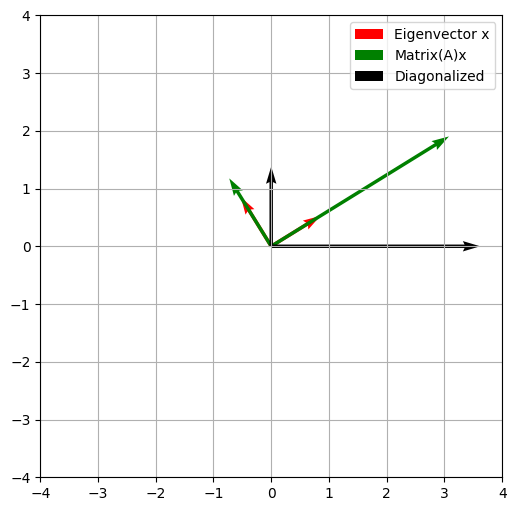

In [3]:
fig, ax = plt.subplots(figsize=(8,6))

ax.quiver(*origin, *x, angles='xy', scale_units='xy', scale=1, color='r', label='Eigenvector x')
ax.quiver(*origin, *Ax, angles='xy', scale_units='xy', scale=1, color='g', label='Matrix(A)x')
ax.quiver(*origin, *res, angles='xy', scale_units='xy', scale=1, color='k', label='Diagonalized')


# eigenvectors
# ax.quiver(*[0,0], *v1, angles='xy', scale_units='xy', scale=1, color='r', label='vector v1')
# ax.quiver(*[0,0], *v2, angles='xy', scale_units='xy', scale=1, color='r', label='vector v2')

# # matrix transformed
# ax.quiver(*[0,0], *Av1, angles='xy', scale_units='xy', scale=1, color='k', label='Matrix(A)v1')
# ax.quiver(*[0,0], *Av2, angles='xy', scale_units='xy', scale=1, color='r', label='Matrix(A)v2')


ax.grid()
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_aspect('equal')
ax.legend()

plt.show()

In [4]:
A = np.array([[3,1,4],
              [1,5,6],
              [4,6,8]])

val,x = np.linalg.eig(A)
origin = np.eye(A.shape[0])

xT = x.T
Ax = A @ x
res = xT @ Ax
# res = x.T @ A @ x

print(x)
print(Ax)
print(np.round(res))

[[-0.32929278 -0.78498777 -0.524748  ]
 [-0.5488213   0.6113458  -0.57013287]
 [-0.76834982 -0.10025224  0.63212977]]
[[ -4.61009892  -2.14462648   0.3841422 ]
 [ -7.6834982    1.67022778   0.41736623]
 [-10.75689748  -0.27389421  -0.46275111]]
[[14. -0.  0.]
 [-0.  3.  0.]
 [ 0.  0. -1.]]


# 3D view

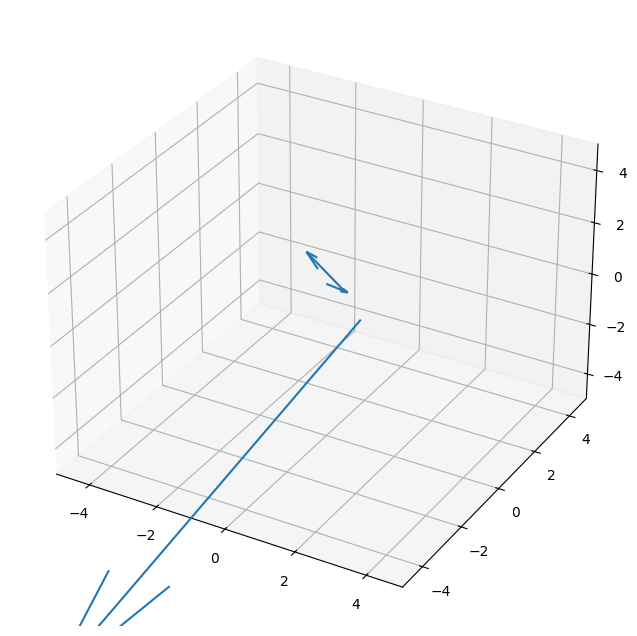

In [5]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(projection='3d')
# ax.quiver(*origin, *x )
ax.quiver(*origin, *Ax)


ax.grid()
ax.set_xlim3d(-5,5)
ax.set_ylim3d(-5,5)
ax.set_zlim3d(-5,5)


plt.show()

# Cholesky Decomposition
A positive matrices can be factorized into product A = LL^T. Where L is lower triangular matrix, Cholesky of A and also L is unique.


first we take a random matrix -> constructed SPD matrix A -> factorized into product  A = LL^T



Cholesky decomposition is independent of how matrix A was created.

In [6]:
# Arbitrary matrix 
matrix = np.array([[2,5,4],
                   [1,5,6],
                   [4,6,3]])

# constructed into symmetric positive definite matrix
cov = matrix @ matrix.T 

# Factorized into product A = LL^T
L = np.linalg.cholesky(cov)  # L -> lower triangular matrix

# Reconstructed cov
A = L @ L.T  # A_new = LL^T ~ A
# reconstructed L
re_L = np.linalg.cholesky(A)  # cd_new ~ cd

# output
print(f"Symmetric Positive Definite matrix =\n {cov}")
print(f"Cholesky Decomposition =\n {L}")
print(f"Reconstruct cov =\n {A}")
print(f"Reconstruct L =\n {re_L}")
print(np.allclose(A, cov))

Symmetric Positive Definite matrix =
 [[45 51 50]
 [51 62 52]
 [50 52 61]]
Cholesky Decomposition =
 [[ 6.70820393  0.          0.        ]
 [ 7.60263112  2.04939015  0.        ]
 [ 7.45355992 -2.27710017  0.50917508]]
Reconstruct cov =
 [[45. 51. 50.]
 [51. 62. 52.]
 [50. 52. 61.]]
Reconstruct L =
 [[ 6.70820393  0.          0.        ]
 [ 7.60263112  2.04939015  0.        ]
 [ 7.45355992 -2.27710017  0.50917508]]
True


In [ ]:
M = np.array([[2,1],[1,3]])
C = M @ M.T
L = np.linalg.cholesky(C)
A = L @ L.T 
np.allclose(C, A)

2

# Factorization Algorithm
Column by column 

In [ ]:
def cholesky(A):
    A = np.float32(A)
    n = A.shape[0]
    L = np.zeros((n, n))
    
    # step 1: Diagonal elements
    for j in range(n):
        s = sum(L[j, k]**2 for k in range(j))
        L[j, j] = (A[j, j] - s) ** 0.5
        
        # Step 2: Elements below the diagonal
        for i in range(j + 1, n):
            p = sum(L[i, k] * L[j, k] for k in range(j))
            L[i, j] = (A[i, j] - p) / L[j, j]
    
    return L

m = np.array([[2,3,1],
              [3,4,2],
              [1,2,9]])

# m = np.array([[3,2],[2,4]])
# convert into symmetric positive definite matrix
c = m @ m.T

print(c)
print(cholesky(c))
print(np.linalg.cholesky(c))   

[[14 20 17]
 [20 29 29]
 [17 29 86]]
[[3.7416575  0.         0.        ]
 [5.34522468 0.65465494 0.        ]
 [4.54344098 7.20117858 3.67425789]]
[[3.74165739 0.         0.        ]
 [5.34522484 0.65465367 0.        ]
 [4.54344111 7.20119038 3.67423461]]
